<a href="https://colab.research.google.com/github/tonasthesecond/cs313-stock-analysis/blob/main/240069_project_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Final project: Time-series data and application to stock markets {-}

This project aims at familiarizing you with time-series data analysis and its application to stock markets. Datasets you will be working on are Nasdaq and Vietnam stock datasets.

### Submission {-}
The structure of submission folder should be organized as follows:

- ./\<StudentID>-project-notebook.ipynb: Jupyter notebook containing source code.
- ./\<StudentID>-project-report.pdf: project report.

The submission folder is named DL4AI-\<StudentID>-project (e.g., DL4AI-2012345-project) and then compressed with the same name.
    
### Evaluation {-}
Project evaluation will be conducted on how you accomplish the assignment requirements. You can refer to the project instruction slide deck for details.

### Deadline {-}
Please visit Canvas for details.

In [ ]:
#@title load libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, LSTM, Dropout
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import glob

In [ ]:
#@title load drive
from google.colab import drive
drive.mount('/content/drive')

import os
MODEL_DIR = '/content/drive/MyDrive/cs313-final-project/models'
os.makedirs(MODEL_DIR, exist_ok=True)

Mounted at /content/drive


# 1: Nasdaq stock price prediction

In [ ]:
#@title setttings
FEATURES = ['Open', 'High', 'Low', 'Close', 'Adjusted Close', 'Volume']
CLOSE_IDX = FEATURES.index('Close')
window_size = 30

In [ ]:
#@title utilities
def split_data(X_data, y_data):
    X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.2, shuffle=False)
    X_train, X_val,  y_train, y_val  = train_test_split(X_train, y_train, test_size=0.2, shuffle=False)
    for arr in [X_train, X_val, X_test]:
        arr = np.array(arr)
    return (np.array(X_train), np.array(X_val),  np.array(X_test),
            np.array(y_train), np.array(y_val),   np.array(y_test))


def normalize_windows(X, y, close_idx=CLOSE_IDX):
    X_norm = X.copy().astype(float)
    y_norm = y.copy().astype(float)
    mins = np.zeros((len(X), X.shape[2]))
    maxs = np.zeros((len(X), X.shape[2]))

    for i in range(len(X)):
        for f in range(X.shape[2]):
            mn, mx = X[i, :, f].min(), X[i, :, f].max()
            denom = mx - mn if mx != mn else 1e-8
            X_norm[i, :, f] = (X[i, :, f] - mn) / denom
            mins[i, f], maxs[i, f] = mn, mx

        mn_c, mx_c = mins[i, close_idx], maxs[i, close_idx]
        denom_c = mx_c - mn_c if mx_c != mn_c else 1e-8
        y_norm[i] = (y[i] - mn_c) / denom_c

    return X_norm, y_norm, mins, maxs


def build_model(window_size, n_features, n_outputs=1):
    model = tf.keras.Sequential([
        Conv1D(64,  kernel_size=3, activation='relu', input_shape=(window_size, n_features), padding='same'),
        MaxPooling1D(pool_size=2),
        Conv1D(128, kernel_size=3, activation='relu', padding='same'),
        MaxPooling1D(2),
        Conv1D(64,  kernel_size=3, activation='relu', padding='same'),
        MaxPooling1D(2),
        Flatten(),
        Dense(100, activation='relu'),
        Dense(n_outputs)
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), loss='mse', metrics=['mse'])
    return model


def train_or_load(model_path, window_size, n_features, n_outputs,
                  X_train_norm, y_train_norm, X_val_norm, y_val_norm,
                  epochs=5, batch_size=512):
    if os.path.exists(model_path):
        print(f"Loading model from {model_path}")
        return tf.keras.models.load_model(model_path), None

    print("No saved model found, training...")
    model = build_model(window_size, n_features, n_outputs)
    history = model.fit(X_train_norm, y_train_norm,
                        validation_data=(X_val_norm, y_val_norm),
                        epochs=epochs, batch_size=batch_size)
    model.save(model_path)
    print(f"Saved to {model_path}")
    return model, history


def evaluate_and_plot(model, X_test_norm, y_test, test_mins, test_maxs,
                      close_idx=CLOSE_IDX, title='Stock prediction',
                      currency='$'):
    y_pred_norm = model.predict(X_test_norm)

    y_pred_denorm = y_pred_norm.copy()
    for i in range(len(y_pred_denorm)):
        mn_c = test_mins[i, close_idx]
        mx_c = test_maxs[i, close_idx]
        y_pred_denorm[i] = y_pred_norm[i] * (mx_c - mn_c) + mn_c

    n_outputs = y_pred_denorm.shape[1]
    first_forecast_day = y_test.shape[1] if y_test.ndim > 1 else 1

    plt.figure(figsize=(16, 8), dpi=300)
    for d in range(n_outputs):
        plt.plot(y_pred_denorm[:, d], label=f'Predicted day +{d+1}', alpha=0.7)
    plt.plot(y_test[:, 0], label=f'Real price (day +{first_forecast_day})', color='black', linewidth=1.5)
    plt.title(title, fontsize=16)
    plt.xlabel('Time (days)', fontsize=14)
    plt.ylabel(f'Close price ({currency})', fontsize=14)
    plt.grid()
    plt.legend()
    plt.show()

    for d in range(n_outputs):
        rmse = np.sqrt(mean_squared_error(y_test[:, d], y_pred_denorm[:, d]))
        mae  = mean_absolute_error(y_test[:, d], y_pred_denorm[:, d])
        print(f"Day +{d+1}  RMSE: {rmse:.4f}  MAE: {mae:.4f}")

    return y_pred_denorm

In [ ]:
#@title load data
nasdaq_files = sorted(glob.glob('nasdaq_data/*.csv'))
data = pd.read_csv(nasdaq_files[0])
print(data.head())
data.info()

         Date    Low  Open  Volume      High  Close  Adjusted Close
0  13-02-1985  0.625   0.0   19680  0.703125  0.625        0.422276
1  14-02-1985  0.625   0.0   65920  0.703125  0.625        0.422276
2  15-02-1985  0.625   0.0   31360  0.703125  0.625        0.422276
3  19-02-1985  0.625   0.0    9120  0.625000  0.625        0.422276
4  20-02-1985  0.625   0.0   40000  0.625000  0.625        0.422276
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9535 entries, 0 to 9534
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            9535 non-null   object 
 1   Low             9535 non-null   float64
 2   Open            9535 non-null   float64
 3   Volume          9535 non-null   int64  
 4   High            9535 non-null   float64
 5   Close           9535 non-null   float64
 6   Adjusted Close  9535 non-null   float64
dtypes: float64(5), int64(1), object(1)
memory usage: 521.6+ KB


## 1.1: Nasdaq multi-feature extension

In [ ]:
#@title windowing
df = data[FEATURES].copy()
X_data, y_data = [], []

for i in range(1, len(df) - window_size - 1):
    window = df.iloc[i : i + window_size].values
    label = df.iloc[i + window_size, CLOSE_IDX]
    X_data.append(window)
    y_data.append([label])

X_data = np.array(X_data)
y_data = np.array(y_data)
print("X_data shape:", X_data.shape)
print("y_data shape:", y_data.shape)

X_data shape: (9503, 30, 6)
y_data shape: (9503, 1)


Loading model from /content/drive/MyDrive/cs313-final-project/models/task1_1.keras
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


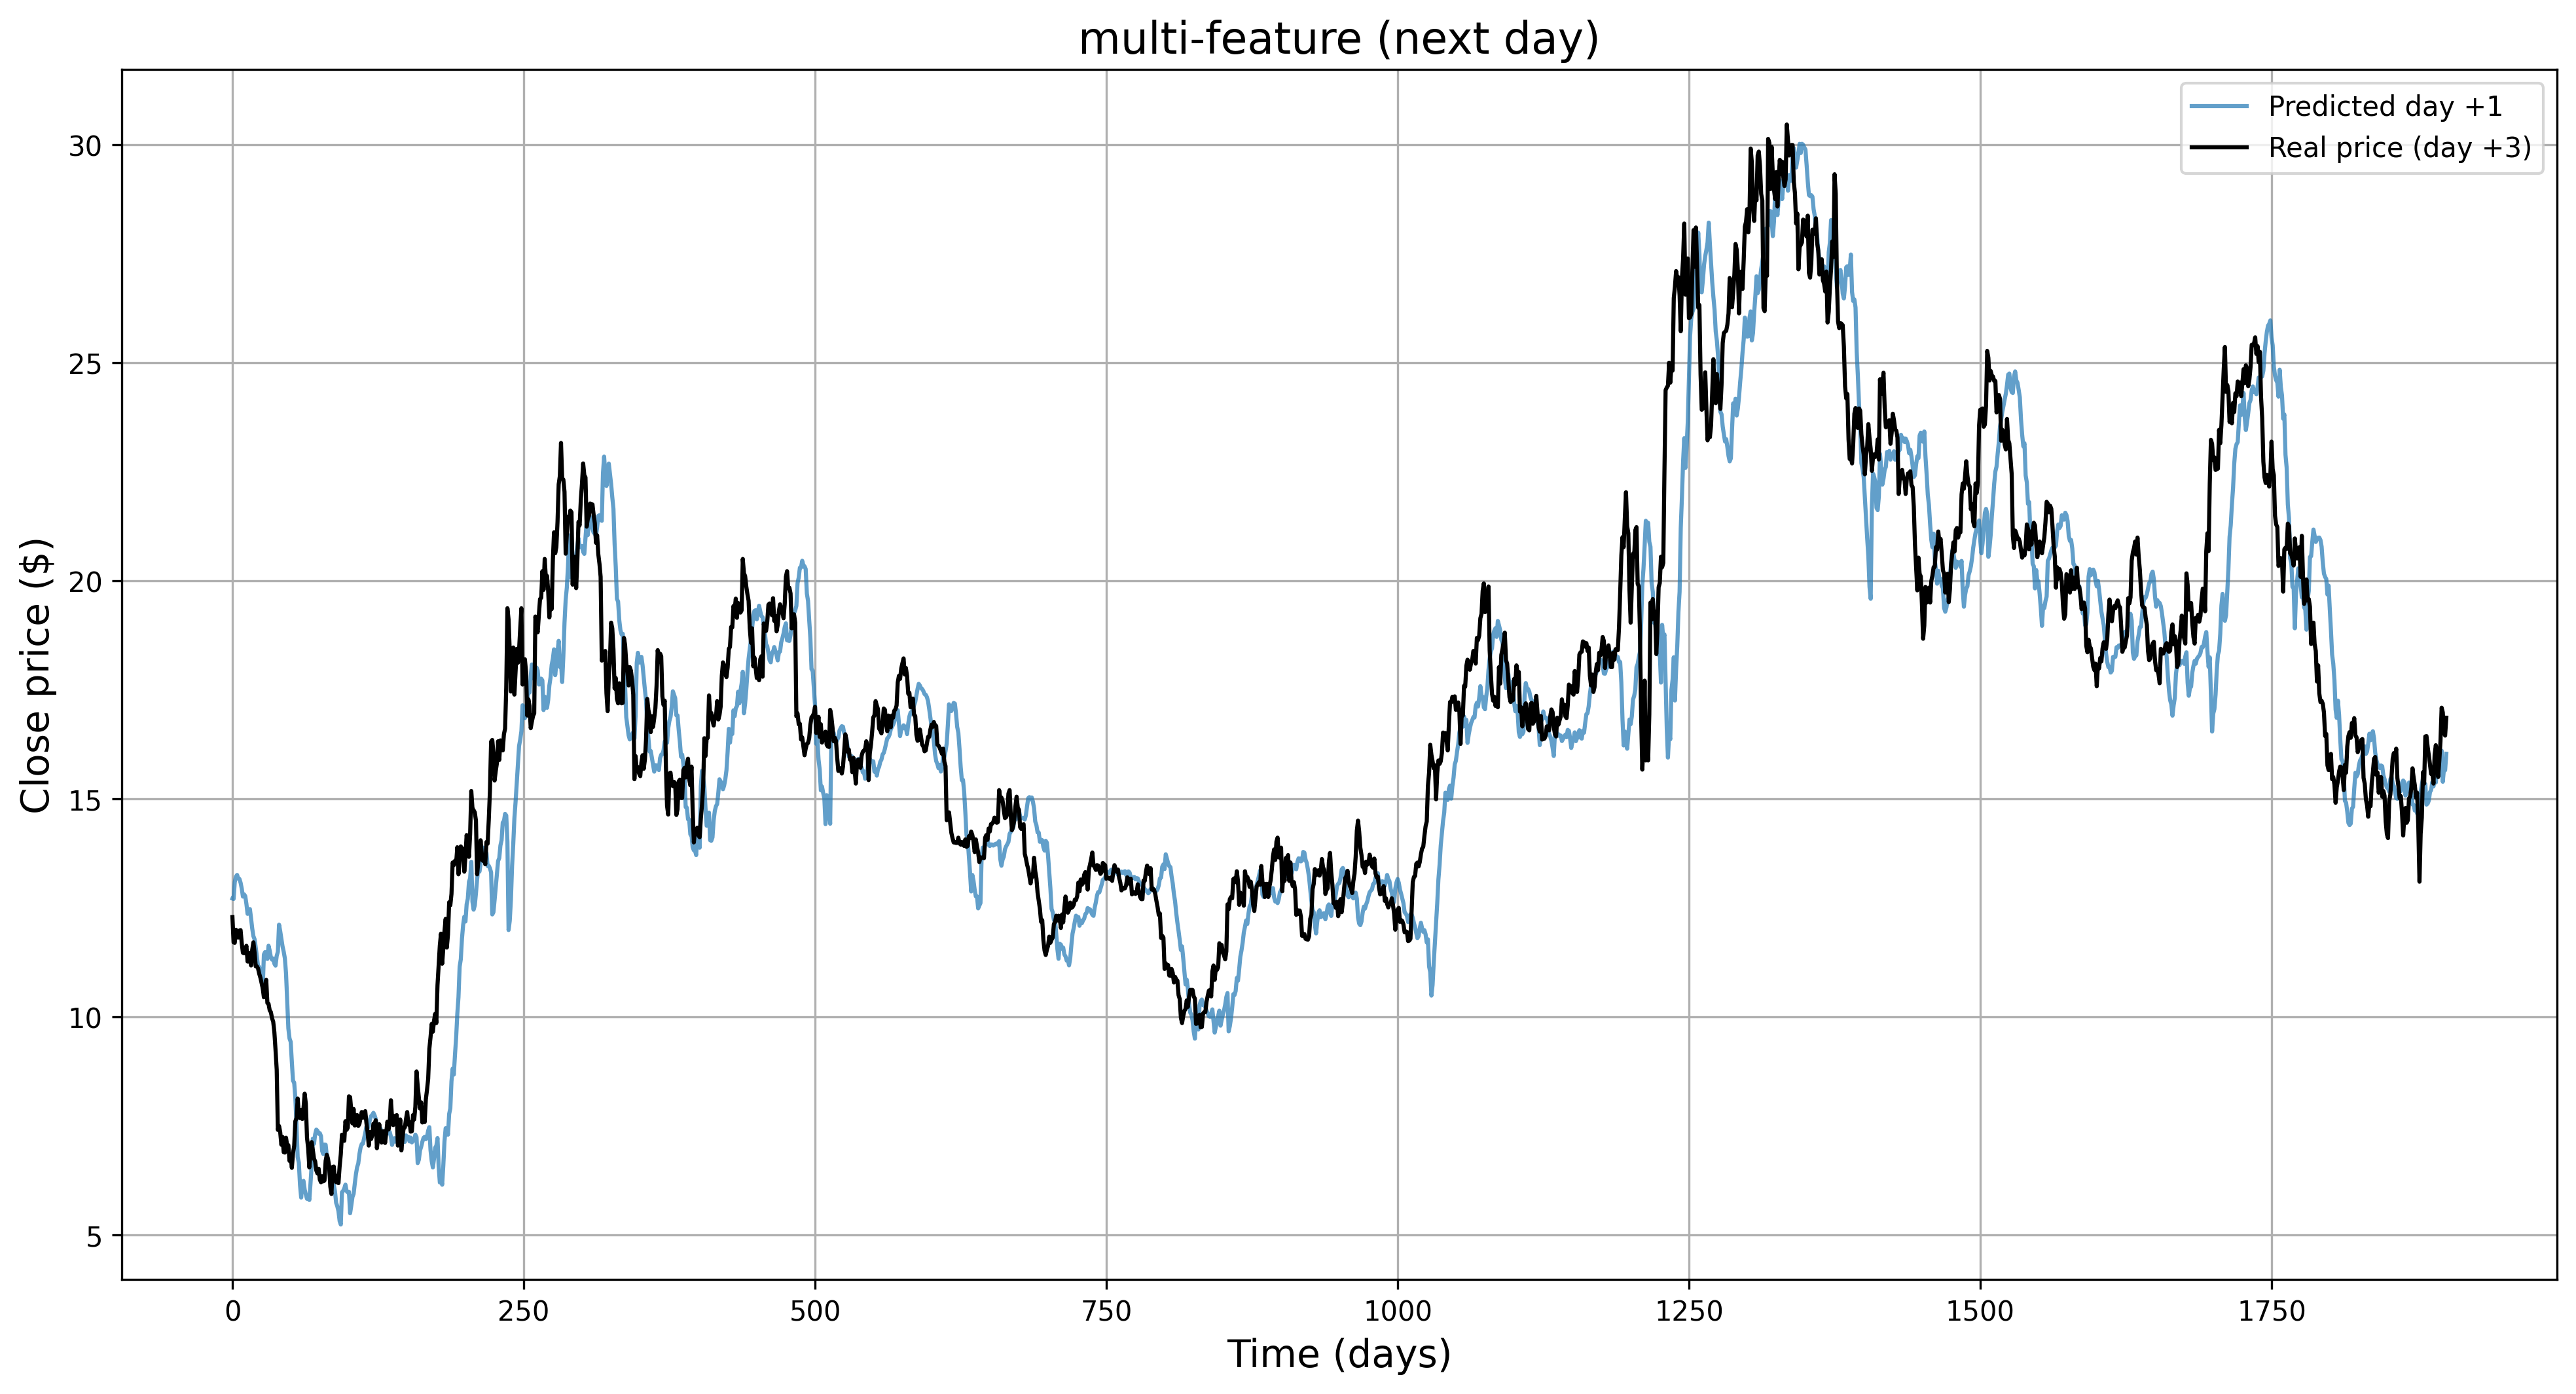

Day +1  RMSE: 1.9235  MAE: 1.3958


In [ ]:
#@title training/loading and evaluating
X_train, X_val, X_test, y_train, y_val, y_test = split_data(X_data, y_data)
X_train_norm, y_train_norm, _, _ = normalize_windows(X_train, y_train)
X_val_norm, y_val_norm, _, _ = normalize_windows(X_val, y_val)
X_test_norm, y_test_norm, t_mins, t_maxs = normalize_windows(X_test, y_test)

model, history = train_or_load(f'{MODEL_DIR}/task1_1.keras',
                                window_size, len(FEATURES), 1,
                                X_train_norm, y_train_norm, X_val_norm, y_val_norm)

# so it doesnt present
_ = evaluate_and_plot(model, X_test_norm, y_test, t_mins, t_maxs, title='multi-feature (next day)')

## 1.2: k-th day forecast

In [ ]:
#@title windowing
FORECAST_DAY = 3

df = data[FEATURES].copy()
X_data, y_data = [], []

for i in range(1, len(df) - window_size - FORECAST_DAY):
    window = df.iloc[i : i + window_size].values
    label = df.iloc[i + window_size + FORECAST_DAY - 1, CLOSE_IDX]
    X_data.append(window)
    y_data.append([label])

X_data = np.array(X_data)
y_data = np.array(y_data)
print("X_data shape:", X_data.shape)
print("y_data shape:", y_data.shape)

X_data shape: (9501, 30, 6)
y_data shape: (9501, 1)


Loading model from /content/drive/MyDrive/cs313-final-project/models/task1_2_day3.keras
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


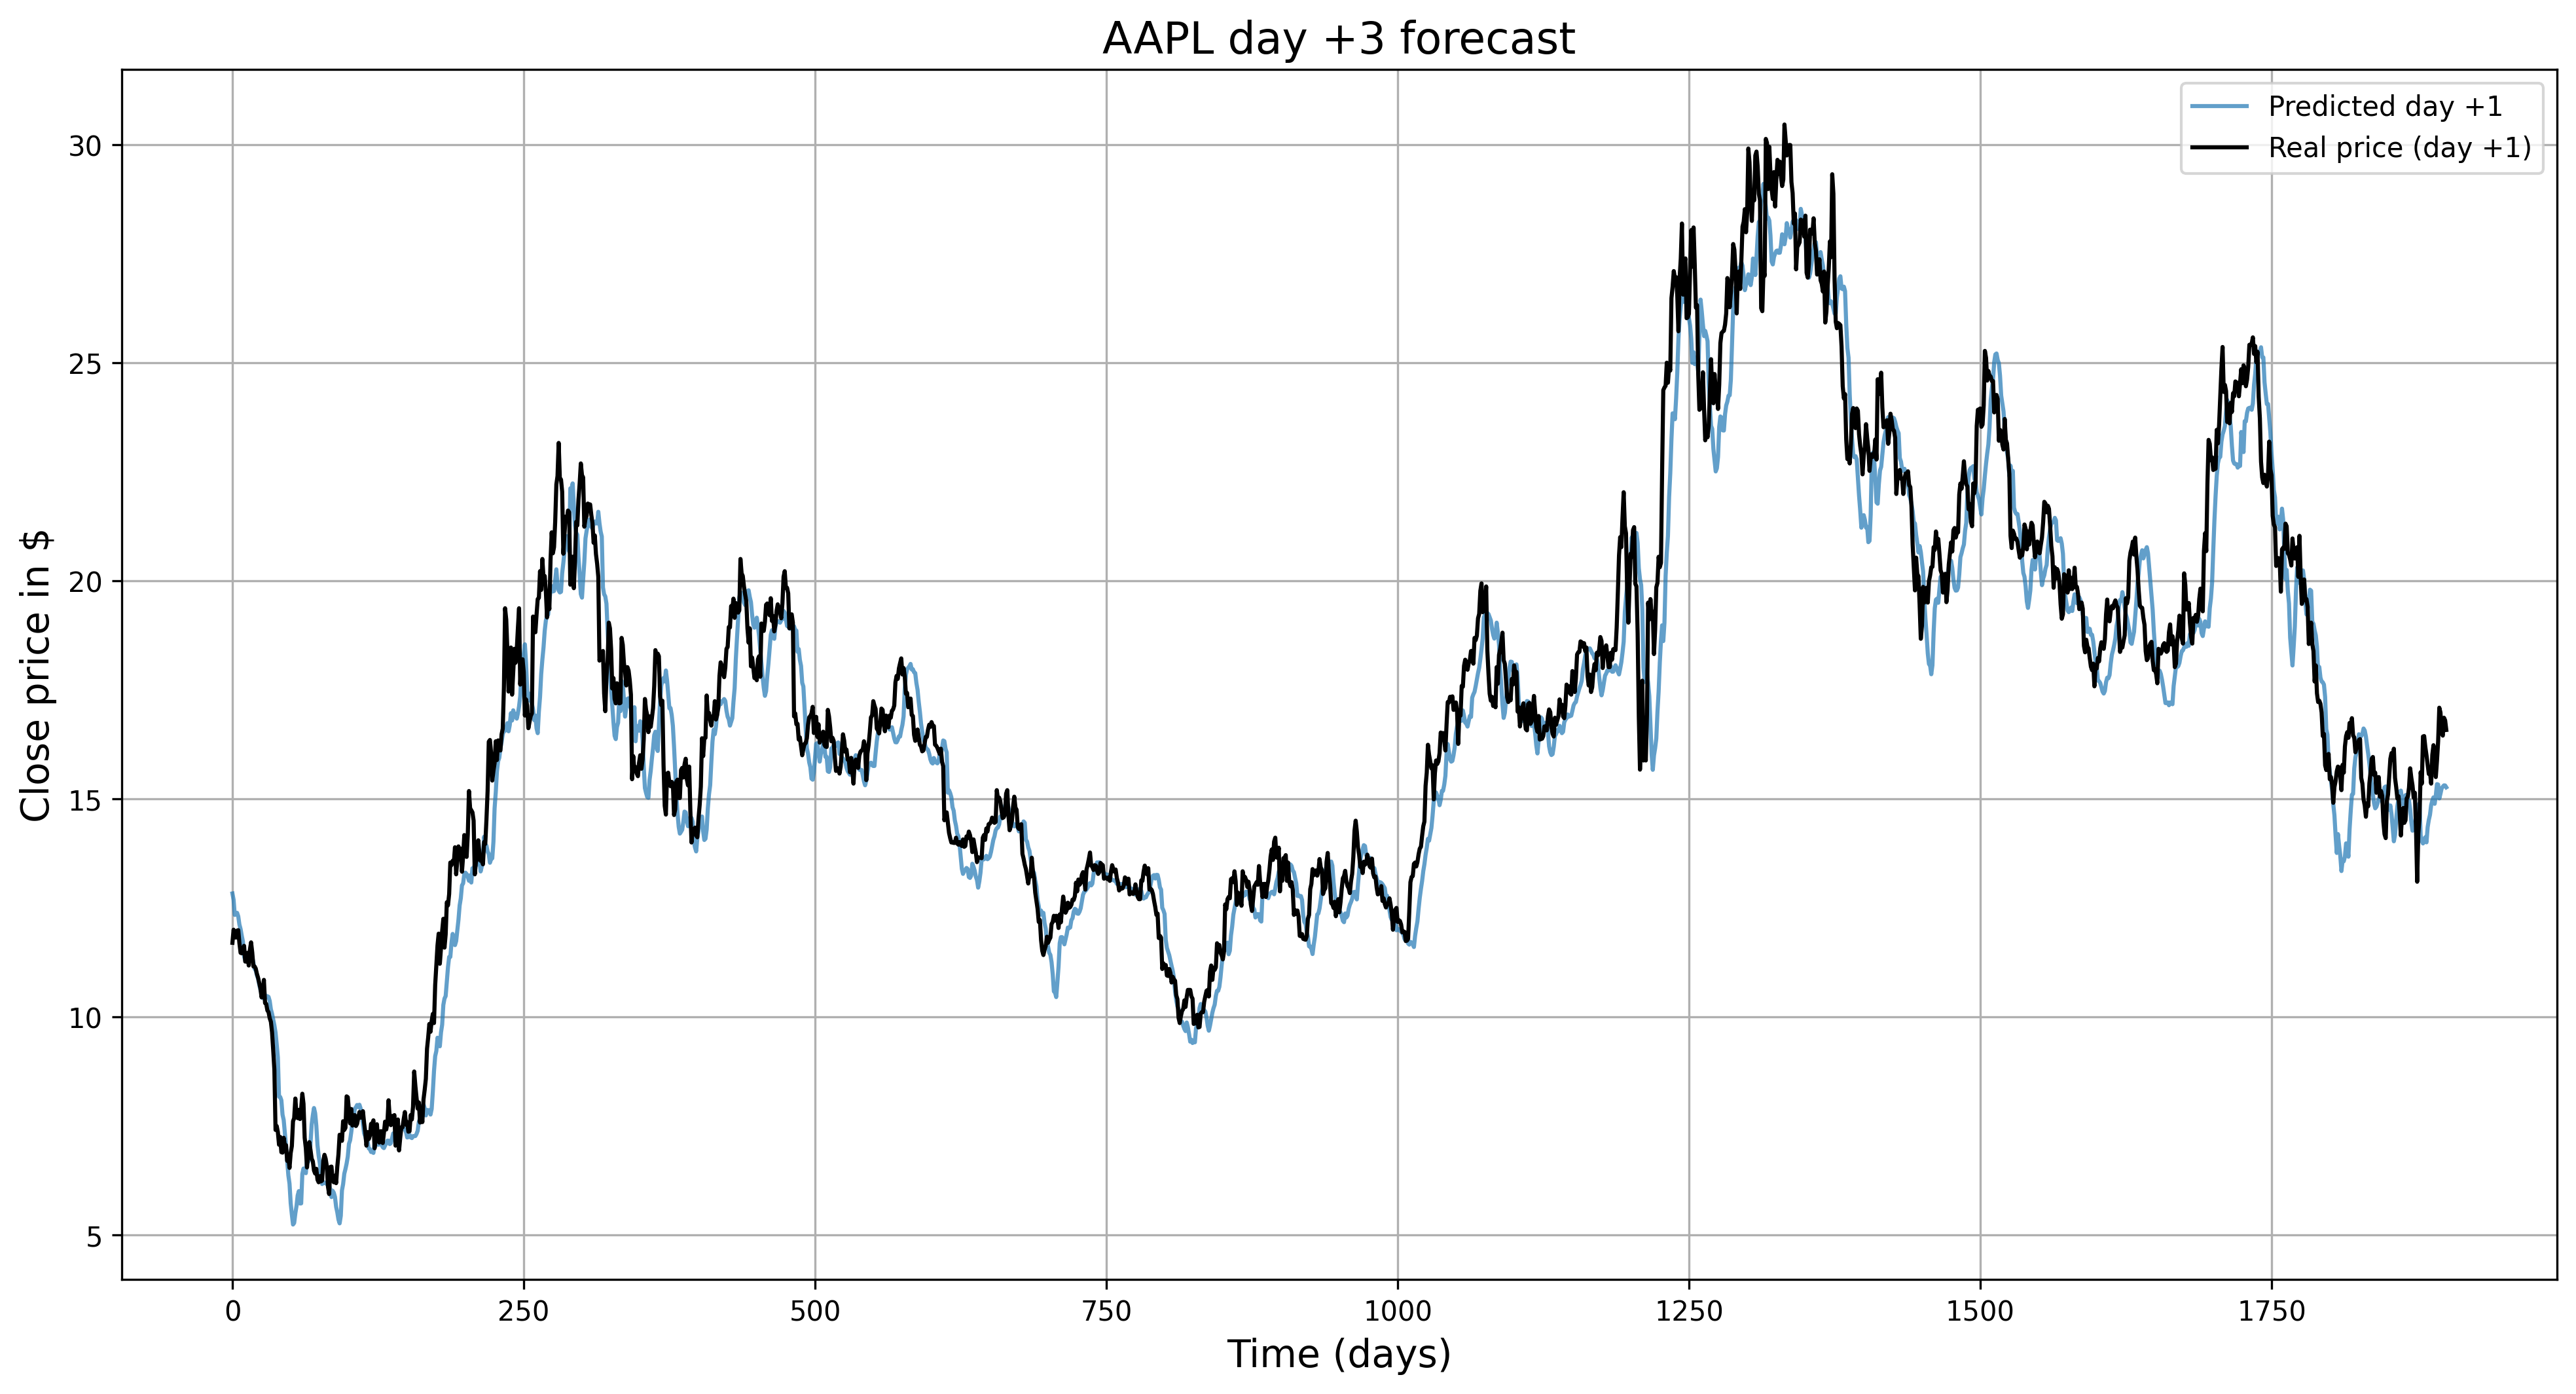

Day +1  RMSE: 1.1820  MAE: 0.9012


array([[12.831328 ],
       [12.6872635],
       [12.339414 ],
       ...,
       [15.309149 ],
       [15.307168 ],
       [15.264606 ]], dtype=float32)

In [ ]:
#@title training/loading and evaluating
X_train, X_val, X_test, y_train, y_val, y_test = split_data(X_data, y_data)
X_train_norm, y_train_norm, _, _ = normalize_windows(X_train, y_train)
X_val_norm, y_val_norm, _, _ = normalize_windows(X_val, y_val)
X_test_norm, y_test_norm, t_mins, t_maxs = normalize_windows(X_test, y_test)

model, history = train_or_load(f'{MODEL_DIR}/task1_2_day{FORECAST_DAY}.keras',
                                window_size, len(FEATURES), 1,
                                X_train_norm, y_train_norm, X_val_norm, y_val_norm)

evaluate_and_plot(model, X_test_norm, y_test, t_mins, t_maxs, title=f'AAPL day +{FORECAST_DAY} forecast')

## 1.3: k-days forecast

In [ ]:
#@title windowing
FORECAST_DAYS = 3

df = data[FEATURES].copy()
X_data, y_data = [], []

for i in range(1, len(df) - window_size - FORECAST_DAYS):
    window = df.iloc[i : i + window_size].values
    labels = df.iloc[i + window_size : i + window_size + FORECAST_DAYS, CLOSE_IDX].values
    X_data.append(window)
    y_data.append(labels)

X_data = np.array(X_data)
y_data = np.array(y_data)
print("X_data shape:", X_data.shape)
print("y_data shape:", y_data.shape)

X_data shape: (9501, 30, 6)
y_data shape: (9501, 3)


Loading model from /content/drive/MyDrive/cs313-final-project/models/task1_3_3days.keras
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


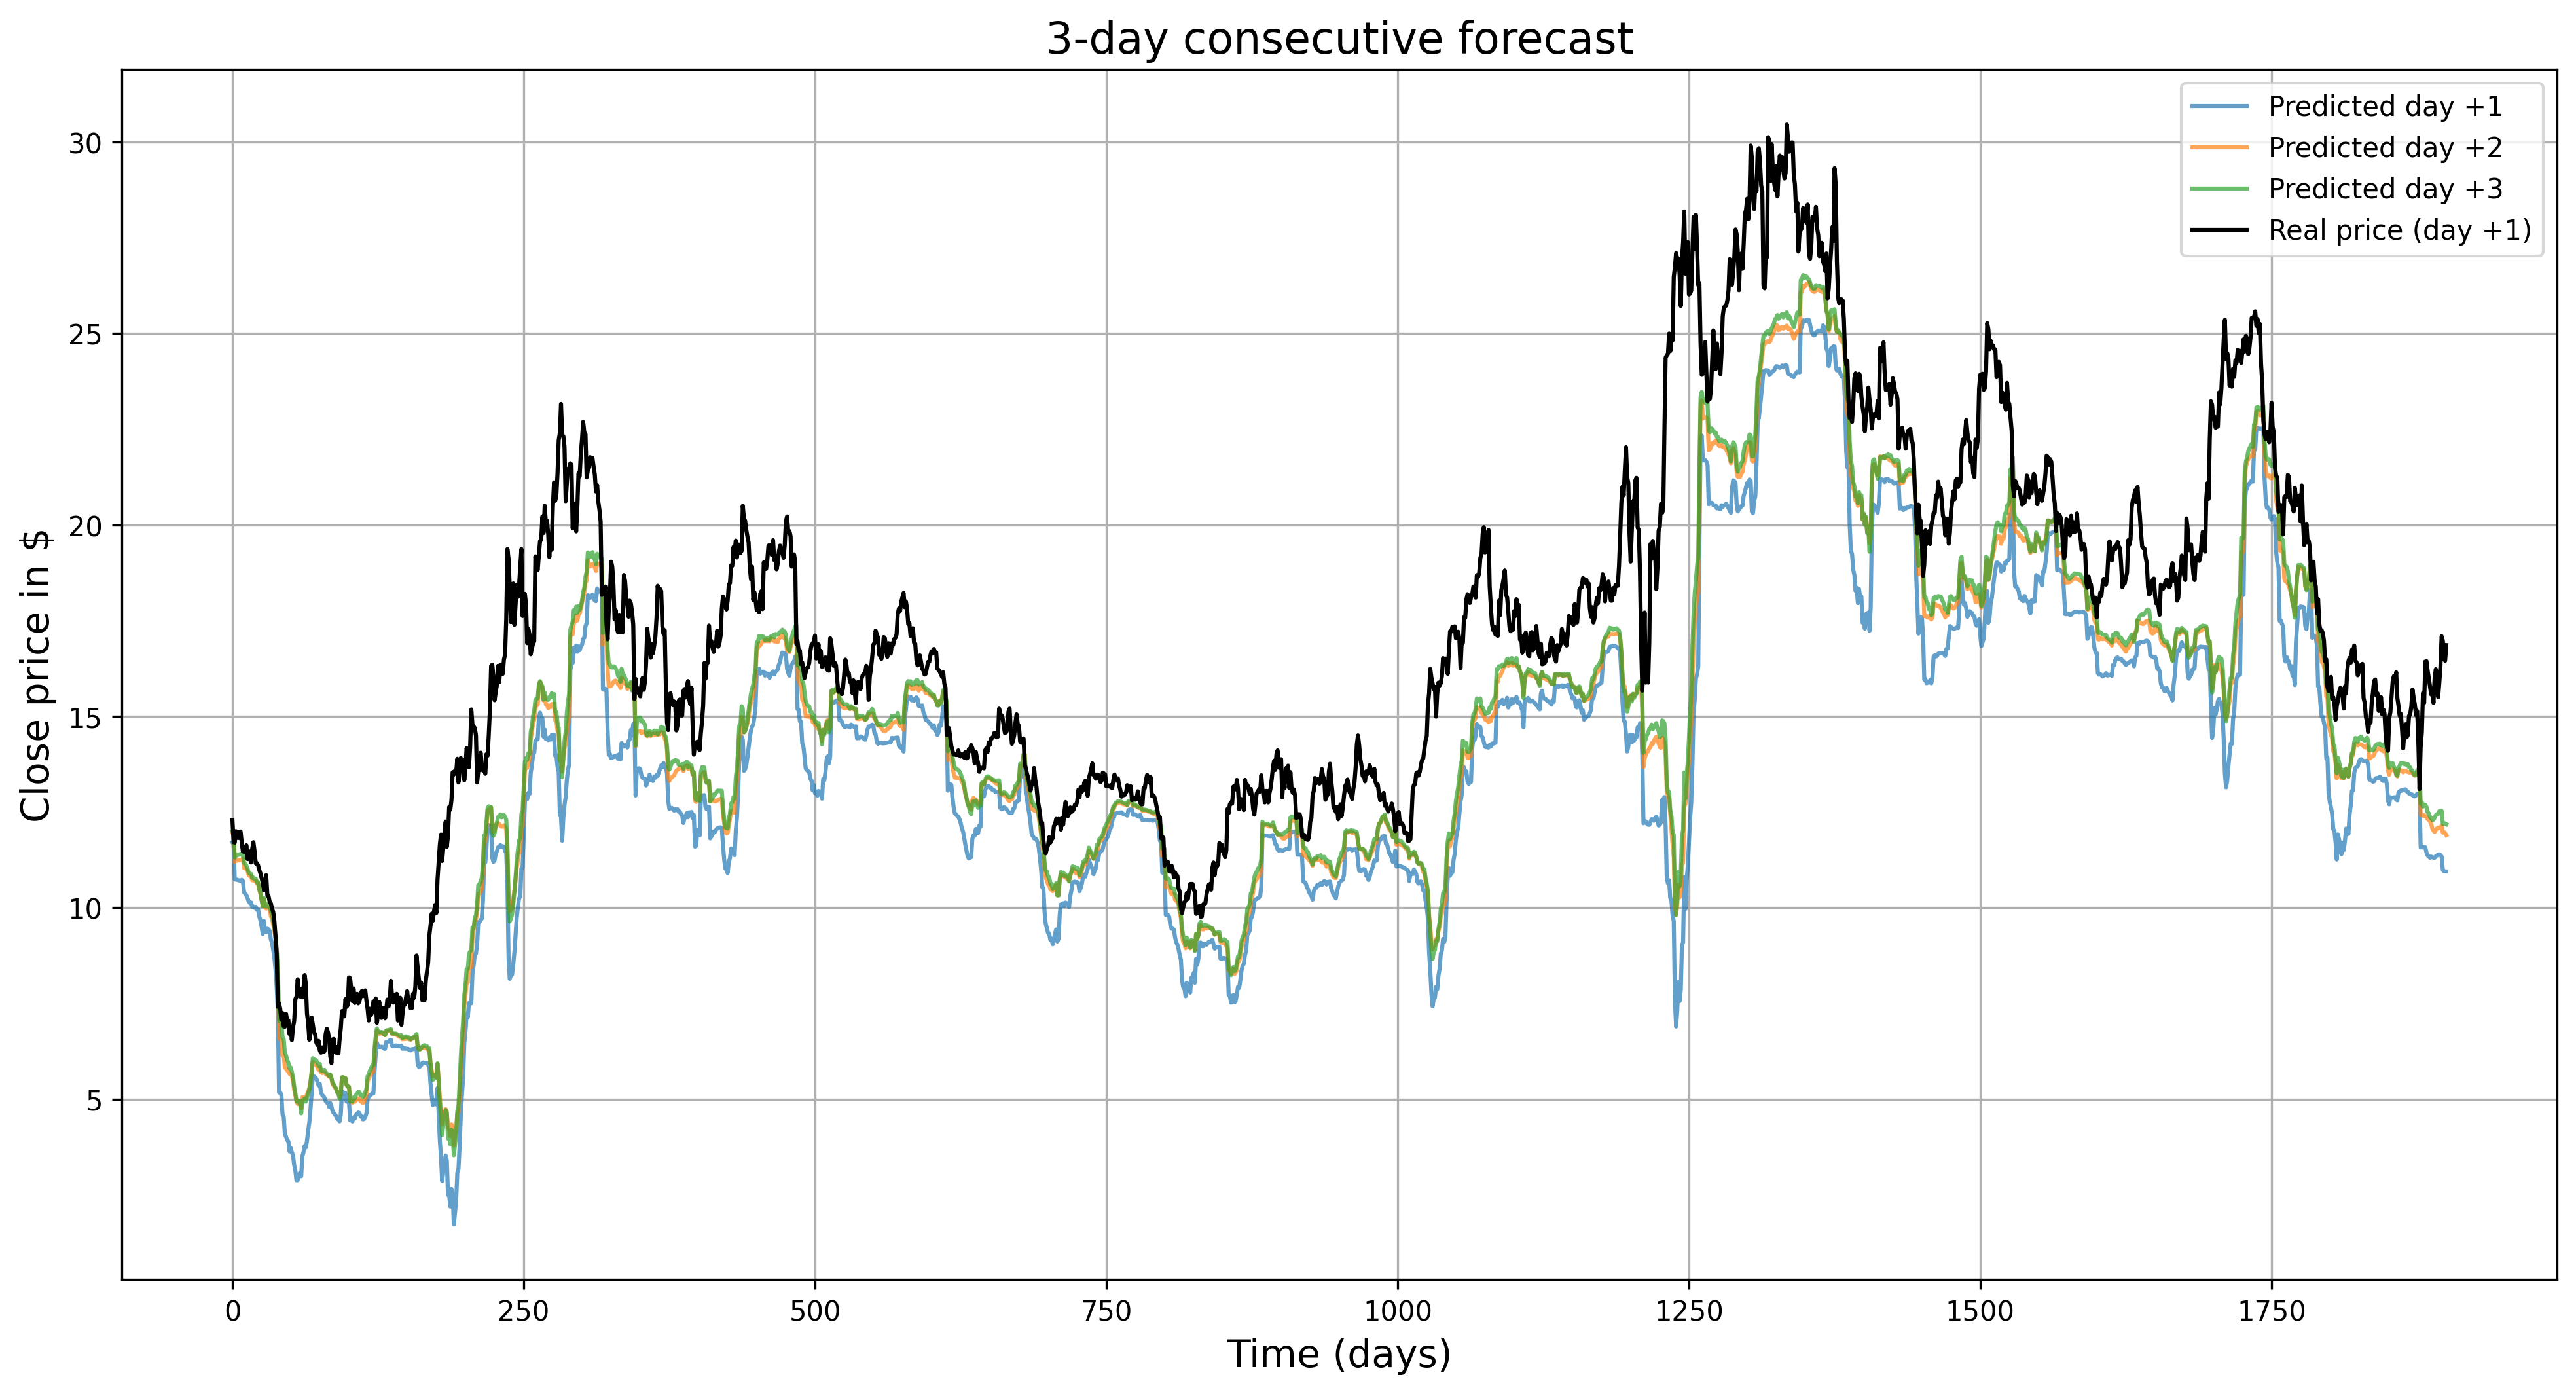

Day +1  RMSE: 4.1810  MAE: 3.3106
Day +2  RMSE: 3.4154  MAE: 2.4972
Day +3  RMSE: 3.3326  MAE: 2.3918


array([[11.705811, 11.956147, 12.000285],
       [11.629903, 11.904423, 11.953322],
       [10.745882, 11.19716 , 11.310631],
       ...,
       [10.952831, 11.975739, 12.210236],
       [10.947978, 11.948739, 12.195772],
       [10.947115, 11.894428, 12.17929 ]], dtype=float32)

In [ ]:
#@title training/loading and evaluating
X_train, X_val, X_test, y_train, y_val, y_test = split_data(X_data, y_data)
X_train_norm, y_train_norm, _, _ = normalize_windows(X_train, y_train)
X_val_norm, y_val_norm, _, _ = normalize_windows(X_val, y_val)
X_test_norm, y_test_norm, t_mins, t_maxs = normalize_windows(X_test, y_test)

model, history = train_or_load(f'{MODEL_DIR}/task1_3_{FORECAST_DAYS}days.keras',
                                window_size, len(FEATURES), FORECAST_DAYS,
                                X_train_norm, y_train_norm, X_val_norm, y_val_norm)

evaluate_and_plot(model, X_test_norm, y_test, t_mins, t_maxs, title=f'{FORECAST_DAYS}-day consecutive forecast')

# 2: Vietnam stock price prediction

In [ ]:
#@title settings
VN_FEATURES = ['Open', 'High', 'Low', 'Close', 'Volume']
VN_CLOSE_IDX = VN_FEATURES.index('Close')  # 3
window_size = 30

In [ ]:
#@title load data
vn_files = sorted(glob.glob('vn_data/*.csv'))
data_vn = pd.read_csv(vn_files[0], index_col=0)
data_vn = data_vn.sort_values('TradingDate').reset_index(drop=True)
print(data_vn[VN_FEATURES].head())
data_vn.info()

      Open     High      Low    Close  Volume
0  32151.0  32151.0  32151.0  32151.0     800
1  32151.0  32151.0  32151.0  32151.0       0
2  32151.0  32151.0  32151.0  32151.0       0
3  32151.0  32151.0  32151.0  32151.0       0
4  34371.0  34371.0  34371.0  34371.0   31030
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1327 entries, 0 to 1326
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Open         1327 non-null   float64
 1   High         1327 non-null   float64
 2   Low          1327 non-null   float64
 3   Close        1327 non-null   float64
 4   Volume       1327 non-null   int64  
 5   TradingDate  1327 non-null   object 
dtypes: float64(4), int64(1), object(1)
memory usage: 62.3+ KB


In [ ]:
#@title utilities
def build_lstm_model(window_size, n_features, n_outputs=1):
    model = tf.keras.Sequential([
        LSTM(128, return_sequences=True, input_shape=(window_size, n_features)),
        Dropout(0.2),
        LSTM(64, return_sequences=False),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(n_outputs)
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
                  loss='mse', metrics=['mse'])
    return model

def train_or_load_lstm(model_path, window_size, n_features, n_outputs,
                       X_train_norm, y_train_norm, X_val_norm, y_val_norm,
                       epochs=20, batch_size=256):
    if os.path.exists(model_path):
        print(f"Loading from {model_path}")
        return tf.keras.models.load_model(model_path), None

    model = build_lstm_model(window_size, n_features, n_outputs)
    history = model.fit(
        X_train_norm, y_train_norm,
        validation_data=(X_val_norm, y_val_norm),
        epochs=epochs, batch_size=batch_size,
        callbacks=[tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)]
    )
    model.save(model_path)
    return model, history


## 2.1: multi-feature next-day LSTM

In [ ]:
#@title windowing
df_vn = data_vn[VN_FEATURES].copy()
X_vn, y_vn = [], []

for i in range(len(df_vn) - window_size - 1):
    window = df_vn.iloc[i : i + window_size].values
    label  = df_vn.iloc[i + window_size, VN_CLOSE_IDX]
    X_vn.append(window)
    y_vn.append([label])

X_vn = np.array(X_vn)
y_vn = np.array(y_vn)
print("X_vn shape:", X_vn.shape)
print("y_vn shape:", y_vn.shape)

X_vn shape: (1296, 30, 5)
y_vn shape: (1296, 1)


Loading from /content/drive/MyDrive/cs313-final-project/models/task2_1.keras
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


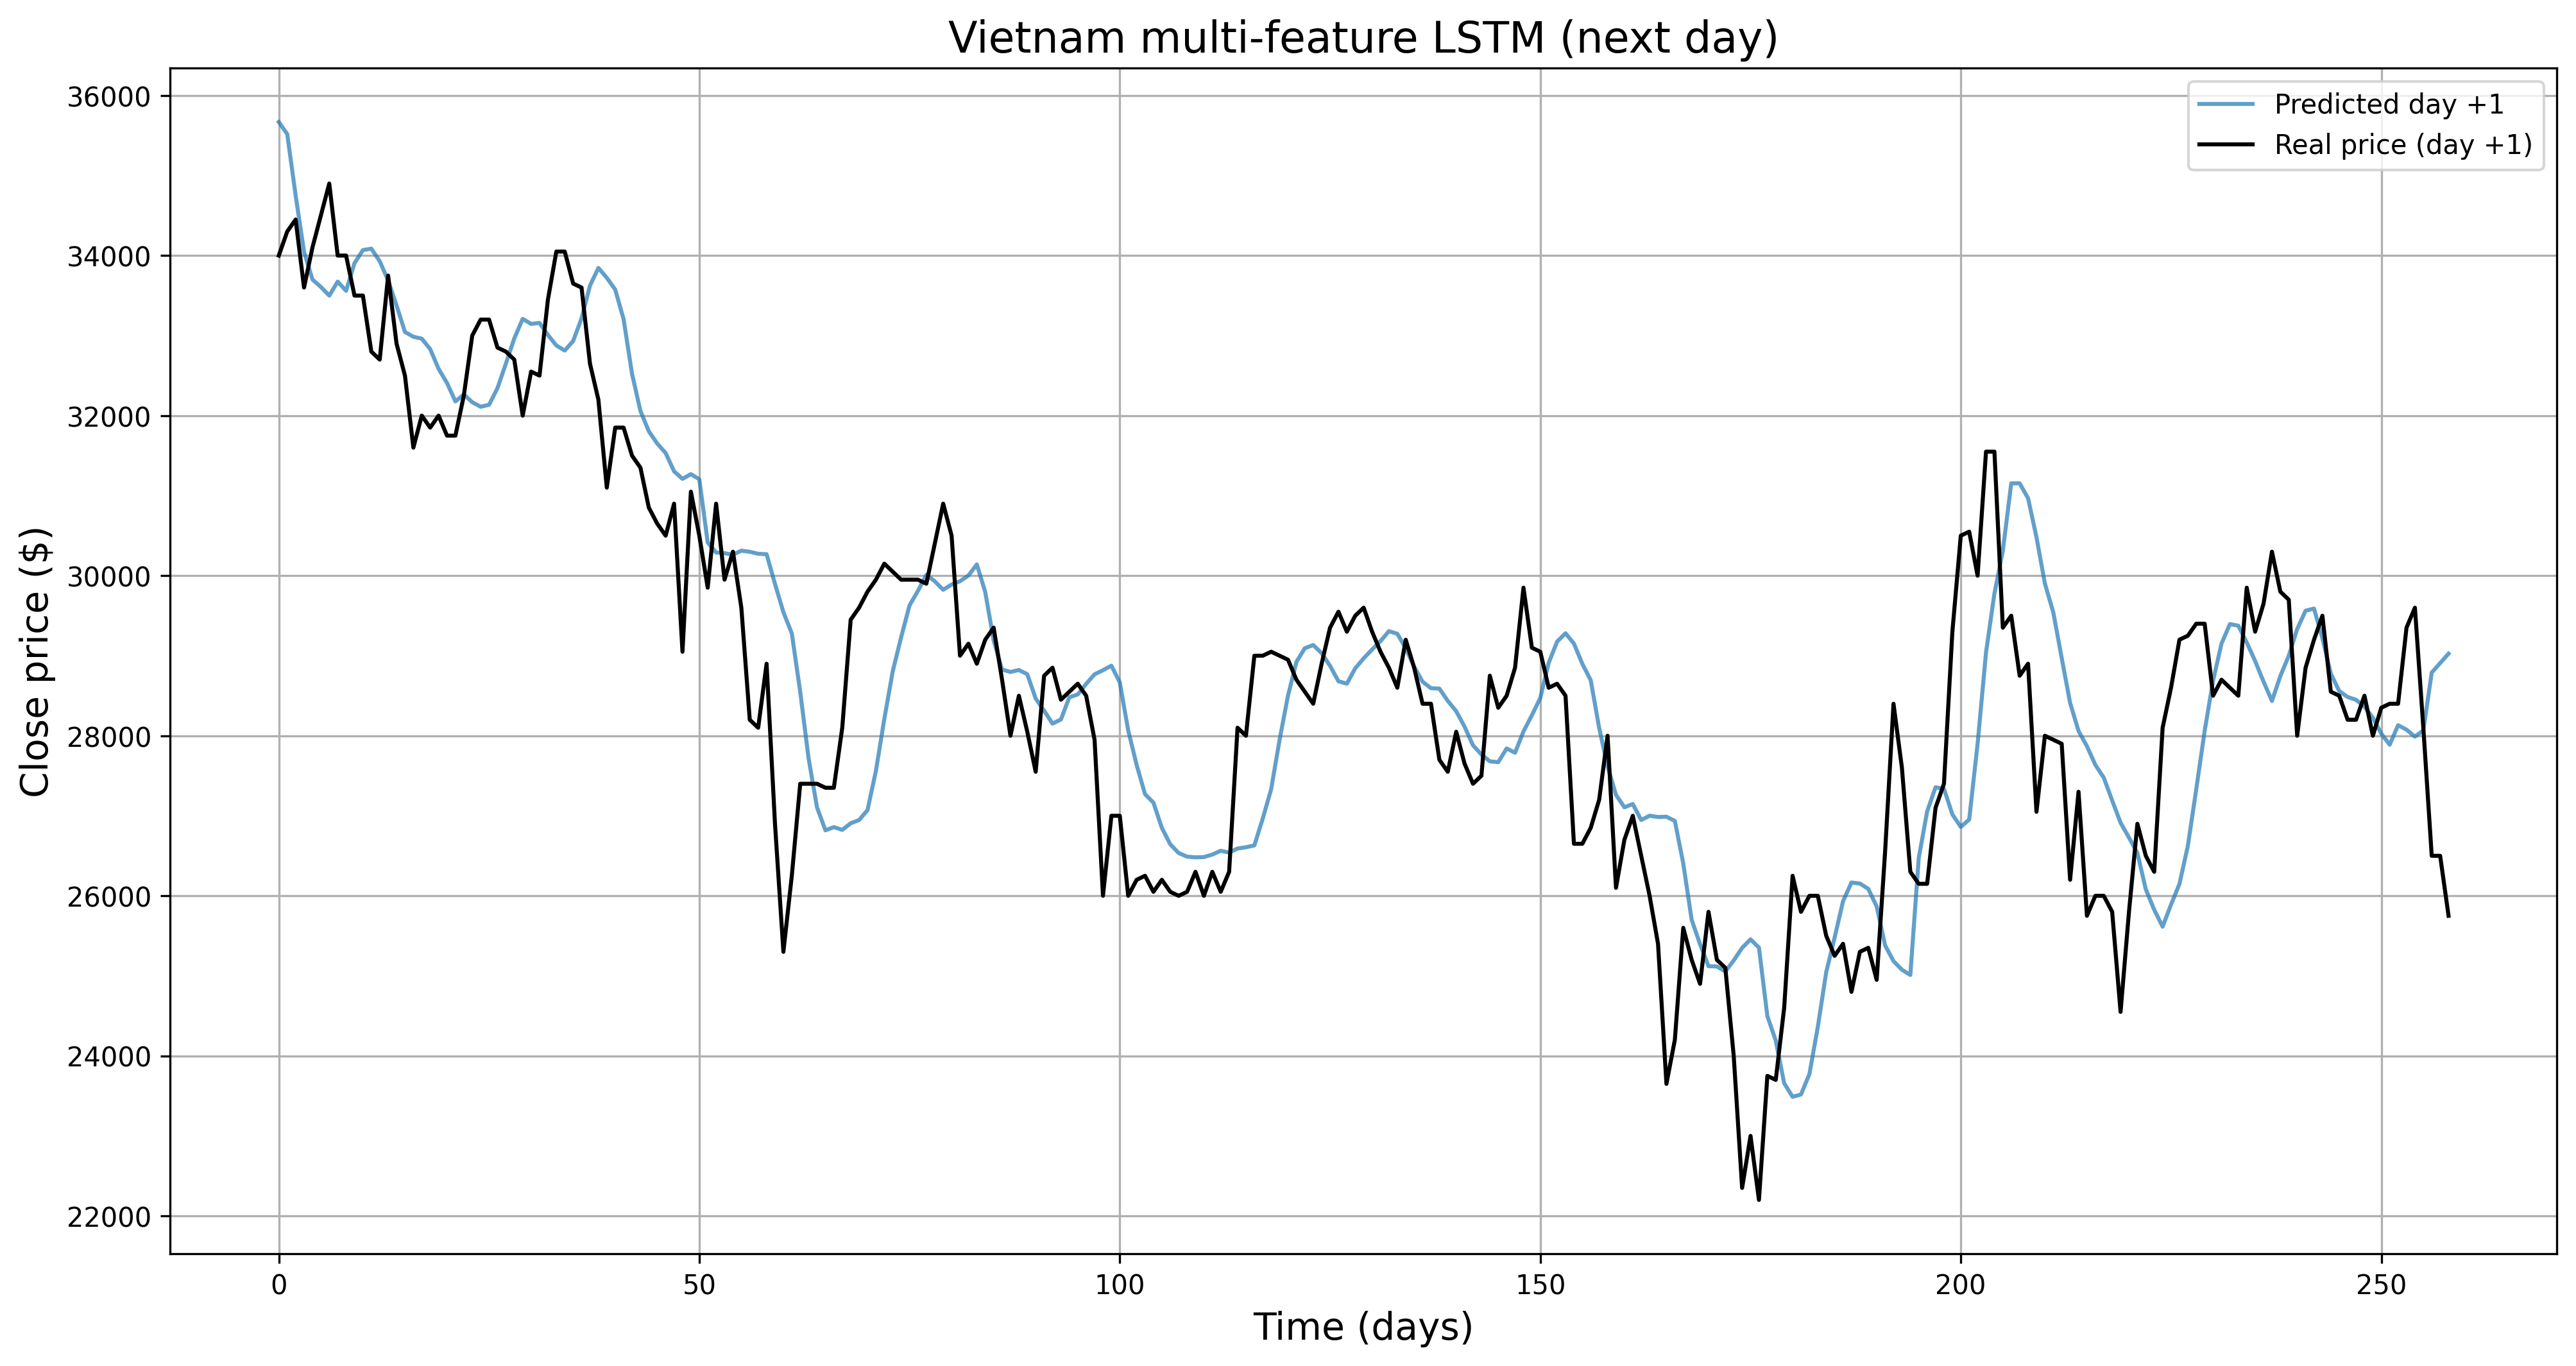

Day +1  RMSE: 1378.9600  MAE: 1069.9091


In [ ]:
#@title training/loading and evaluating
X_train, X_val, X_test, y_train, y_val, y_test = split_data(X_vn, y_vn)
X_train_norm, y_train_norm, _, _           = normalize_windows(X_train, y_train, VN_CLOSE_IDX)
X_val_norm,   y_val_norm,   _, _           = normalize_windows(X_val,   y_val,   VN_CLOSE_IDX)
X_test_norm,  y_test_norm,  t_mins, t_maxs = normalize_windows(X_test,  y_test,  VN_CLOSE_IDX)

model_vn, history = train_or_load_lstm(
    f'{MODEL_DIR}/task2_1.keras',
    window_size, len(VN_FEATURES), 1,
    X_train_norm, y_train_norm, X_val_norm, y_val_norm
)

# so it doesnt return the vallue
_ = evaluate_and_plot(model_vn, X_test_norm, y_test, t_mins, t_maxs,
                  close_idx=VN_CLOSE_IDX, title='Vietnam multi-feature LSTM (next day)')

## 2.2: k-th day forecast

In [ ]:
#@title settings
FORECAST_DAY = 3

In [ ]:
#@title windowing
df_vn = data_vn[VN_FEATURES].copy()
X_vn, y_vn = [], []

for i in range(len(df_vn) - window_size - FORECAST_DAY):
    window = df_vn.iloc[i : i + window_size].values
    label  = df_vn.iloc[i + window_size + FORECAST_DAY - 1, VN_CLOSE_IDX]
    X_vn.append(window)
    y_vn.append([label])

X_vn = np.array(X_vn)
y_vn = np.array(y_vn)
print("X_vn shape:", X_vn.shape)
print("y_vn shape:", y_vn.shape)

X_vn shape: (1294, 30, 5)
y_vn shape: (1294, 1)


Loading from /content/drive/MyDrive/cs313-final-project/models/task2_2_day3.keras
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


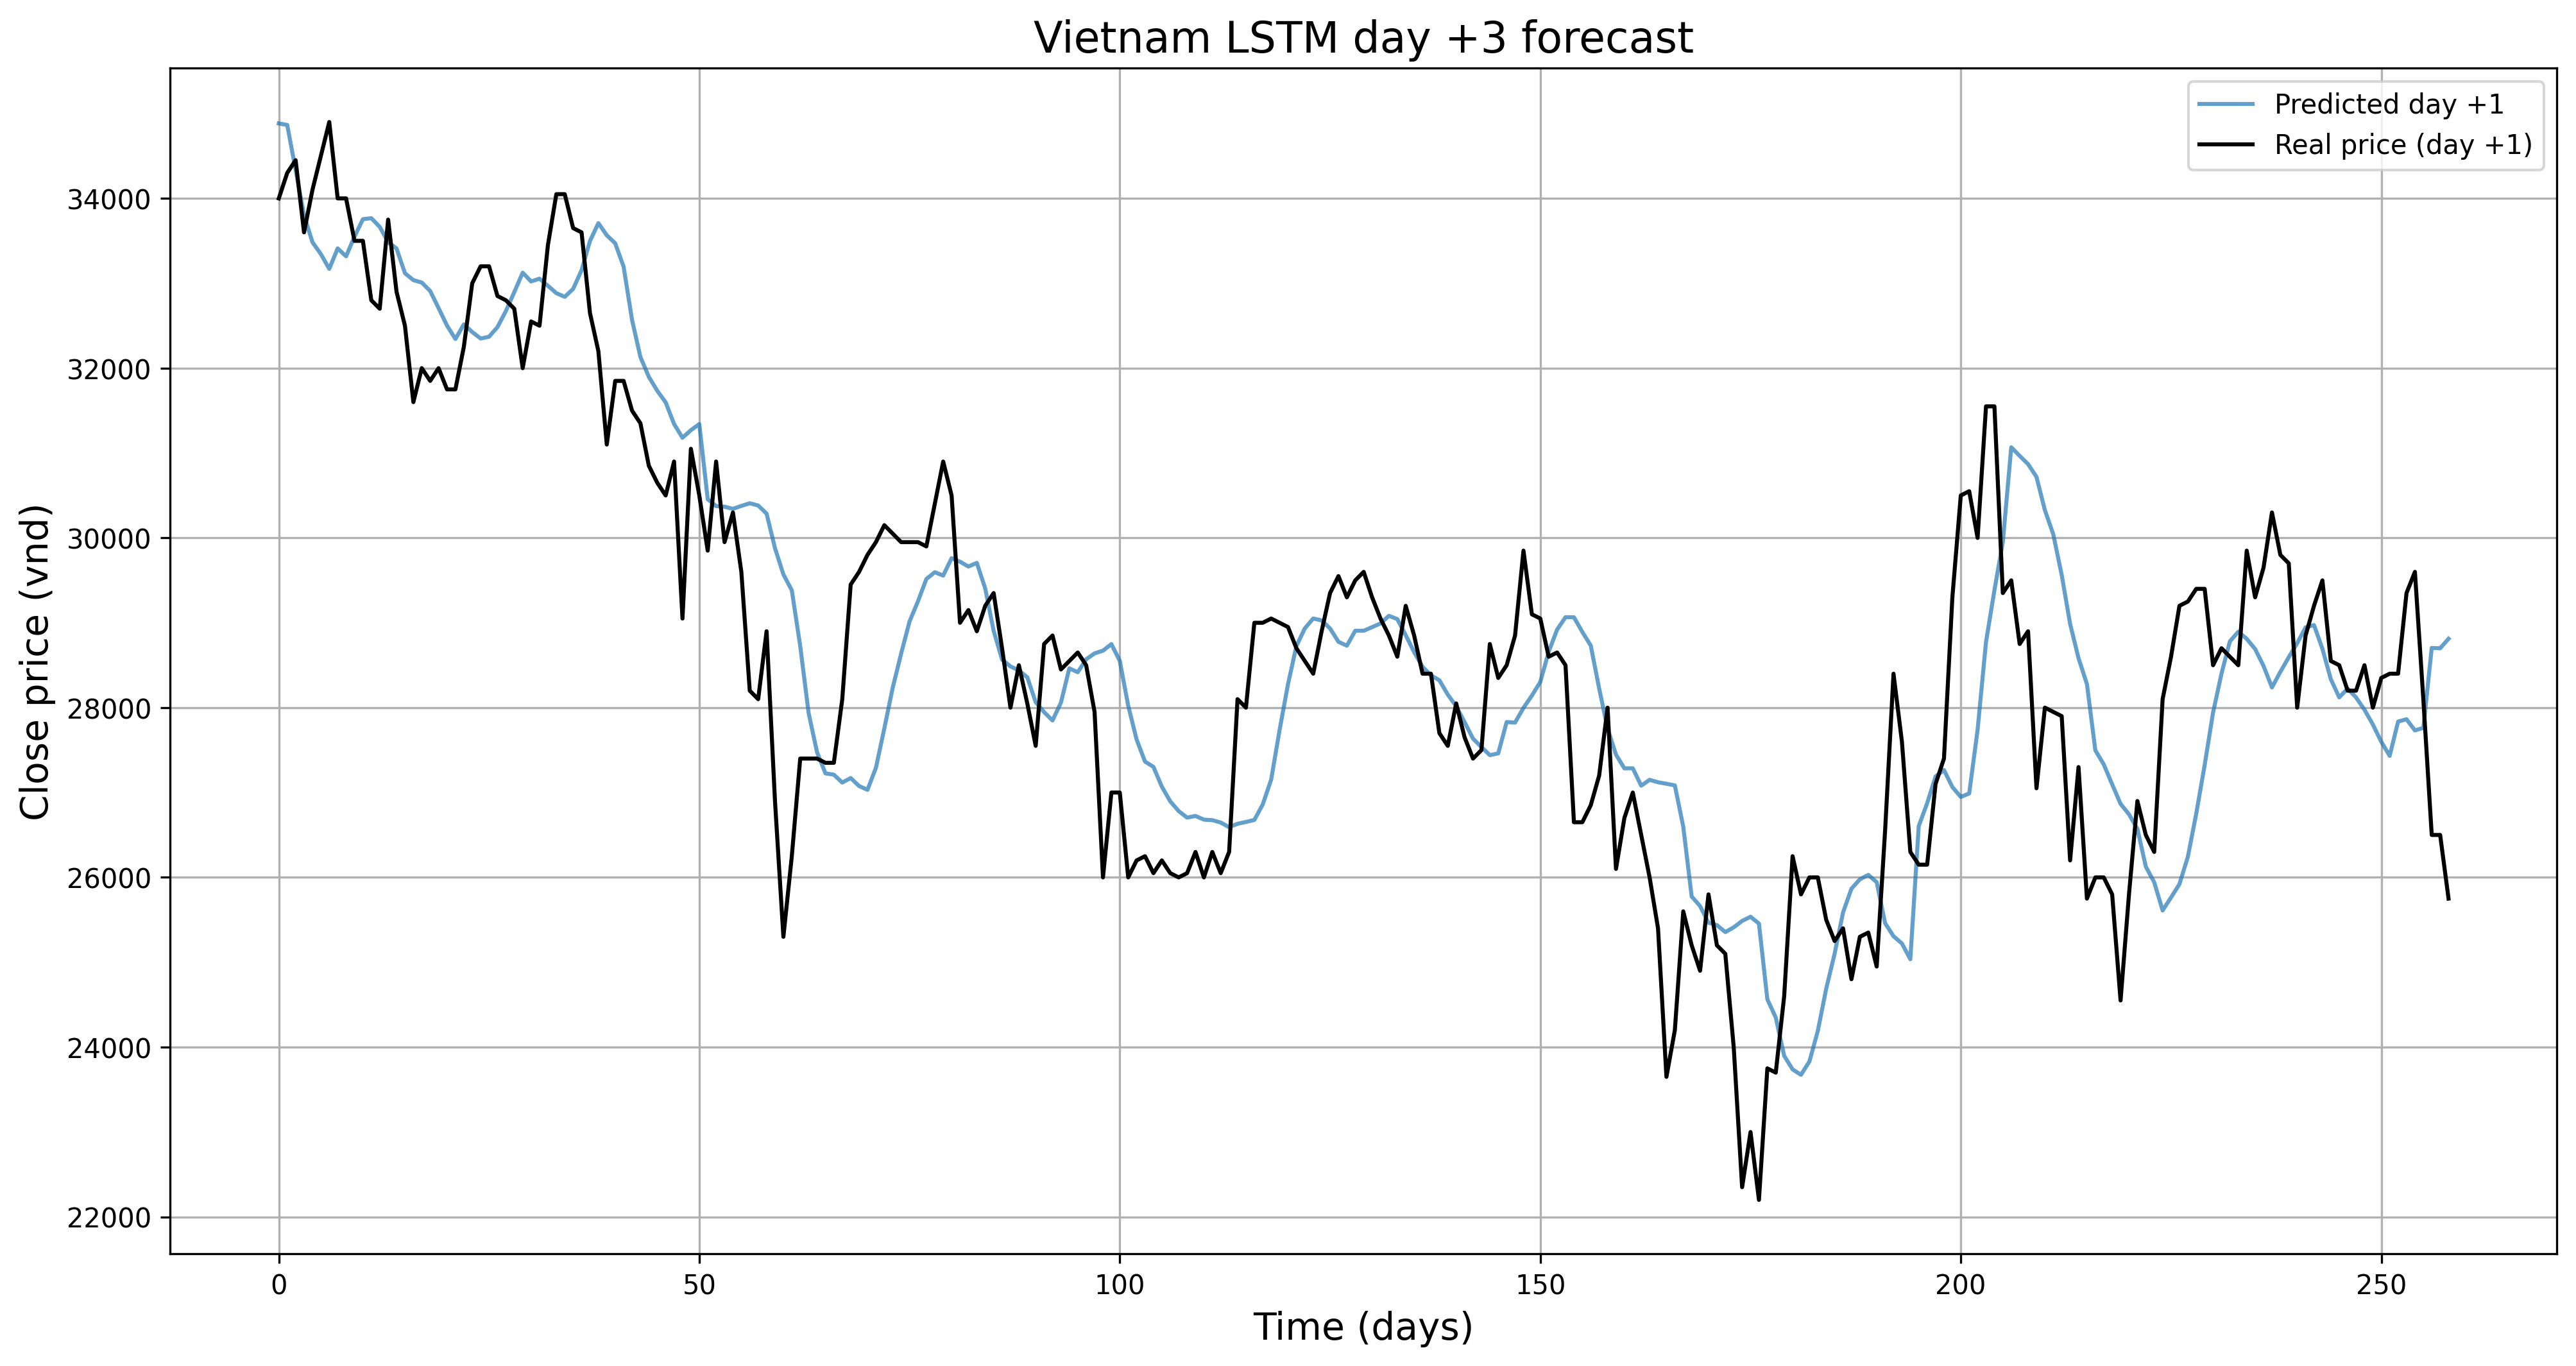

Day +1  RMSE: 1415.7201  MAE: 1094.3178


In [ ]:
#@title training/loading and evaluating
X_train, X_val, X_test, y_train, y_val, y_test = split_data(X_vn, y_vn)
X_train_norm, y_train_norm, _, _           = normalize_windows(X_train, y_train, VN_CLOSE_IDX)
X_val_norm,   y_val_norm,   _, _           = normalize_windows(X_val,   y_val,   VN_CLOSE_IDX)
X_test_norm,  y_test_norm,  t_mins, t_maxs = normalize_windows(X_test,  y_test,  VN_CLOSE_IDX)

model_vn_kth, history = train_or_load_lstm(
    f'{MODEL_DIR}/task2_2_day{FORECAST_DAY}.keras',
    window_size, len(VN_FEATURES), 1,
    X_train_norm, y_train_norm, X_val_norm, y_val_norm
)

_ = evaluate_and_plot(model_vn_kth, X_test_norm, y_test, t_mins, t_maxs,
                  close_idx=VN_CLOSE_IDX, title=f'Vietnam LSTM day +{FORECAST_DAY} forecast', currency='vnd')

## 2.3: k-days forecast

In [ ]:
#@title settings
FORECAST_DAYS = 3

In [ ]:
#@title windowing
df_vn = data_vn[VN_FEATURES].copy()
X_vn, y_vn = [], []

for i in range(len(df_vn) - window_size - FORECAST_DAYS):
    window = df_vn.iloc[i : i + window_size].values
    labels = df_vn.iloc[i + window_size : i + window_size + FORECAST_DAYS, VN_CLOSE_IDX].values
    X_vn.append(window)
    y_vn.append(labels)

X_vn = np.array(X_vn)
y_vn = np.array(y_vn)
print("X_vn shape:", X_vn.shape)
print("y_vn shape:", y_vn.shape)

X_vn shape: (1294, 30, 5)
y_vn shape: (1294, 3)


Loading from /content/drive/MyDrive/cs313-final-project/models/task2_3_3days.keras
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


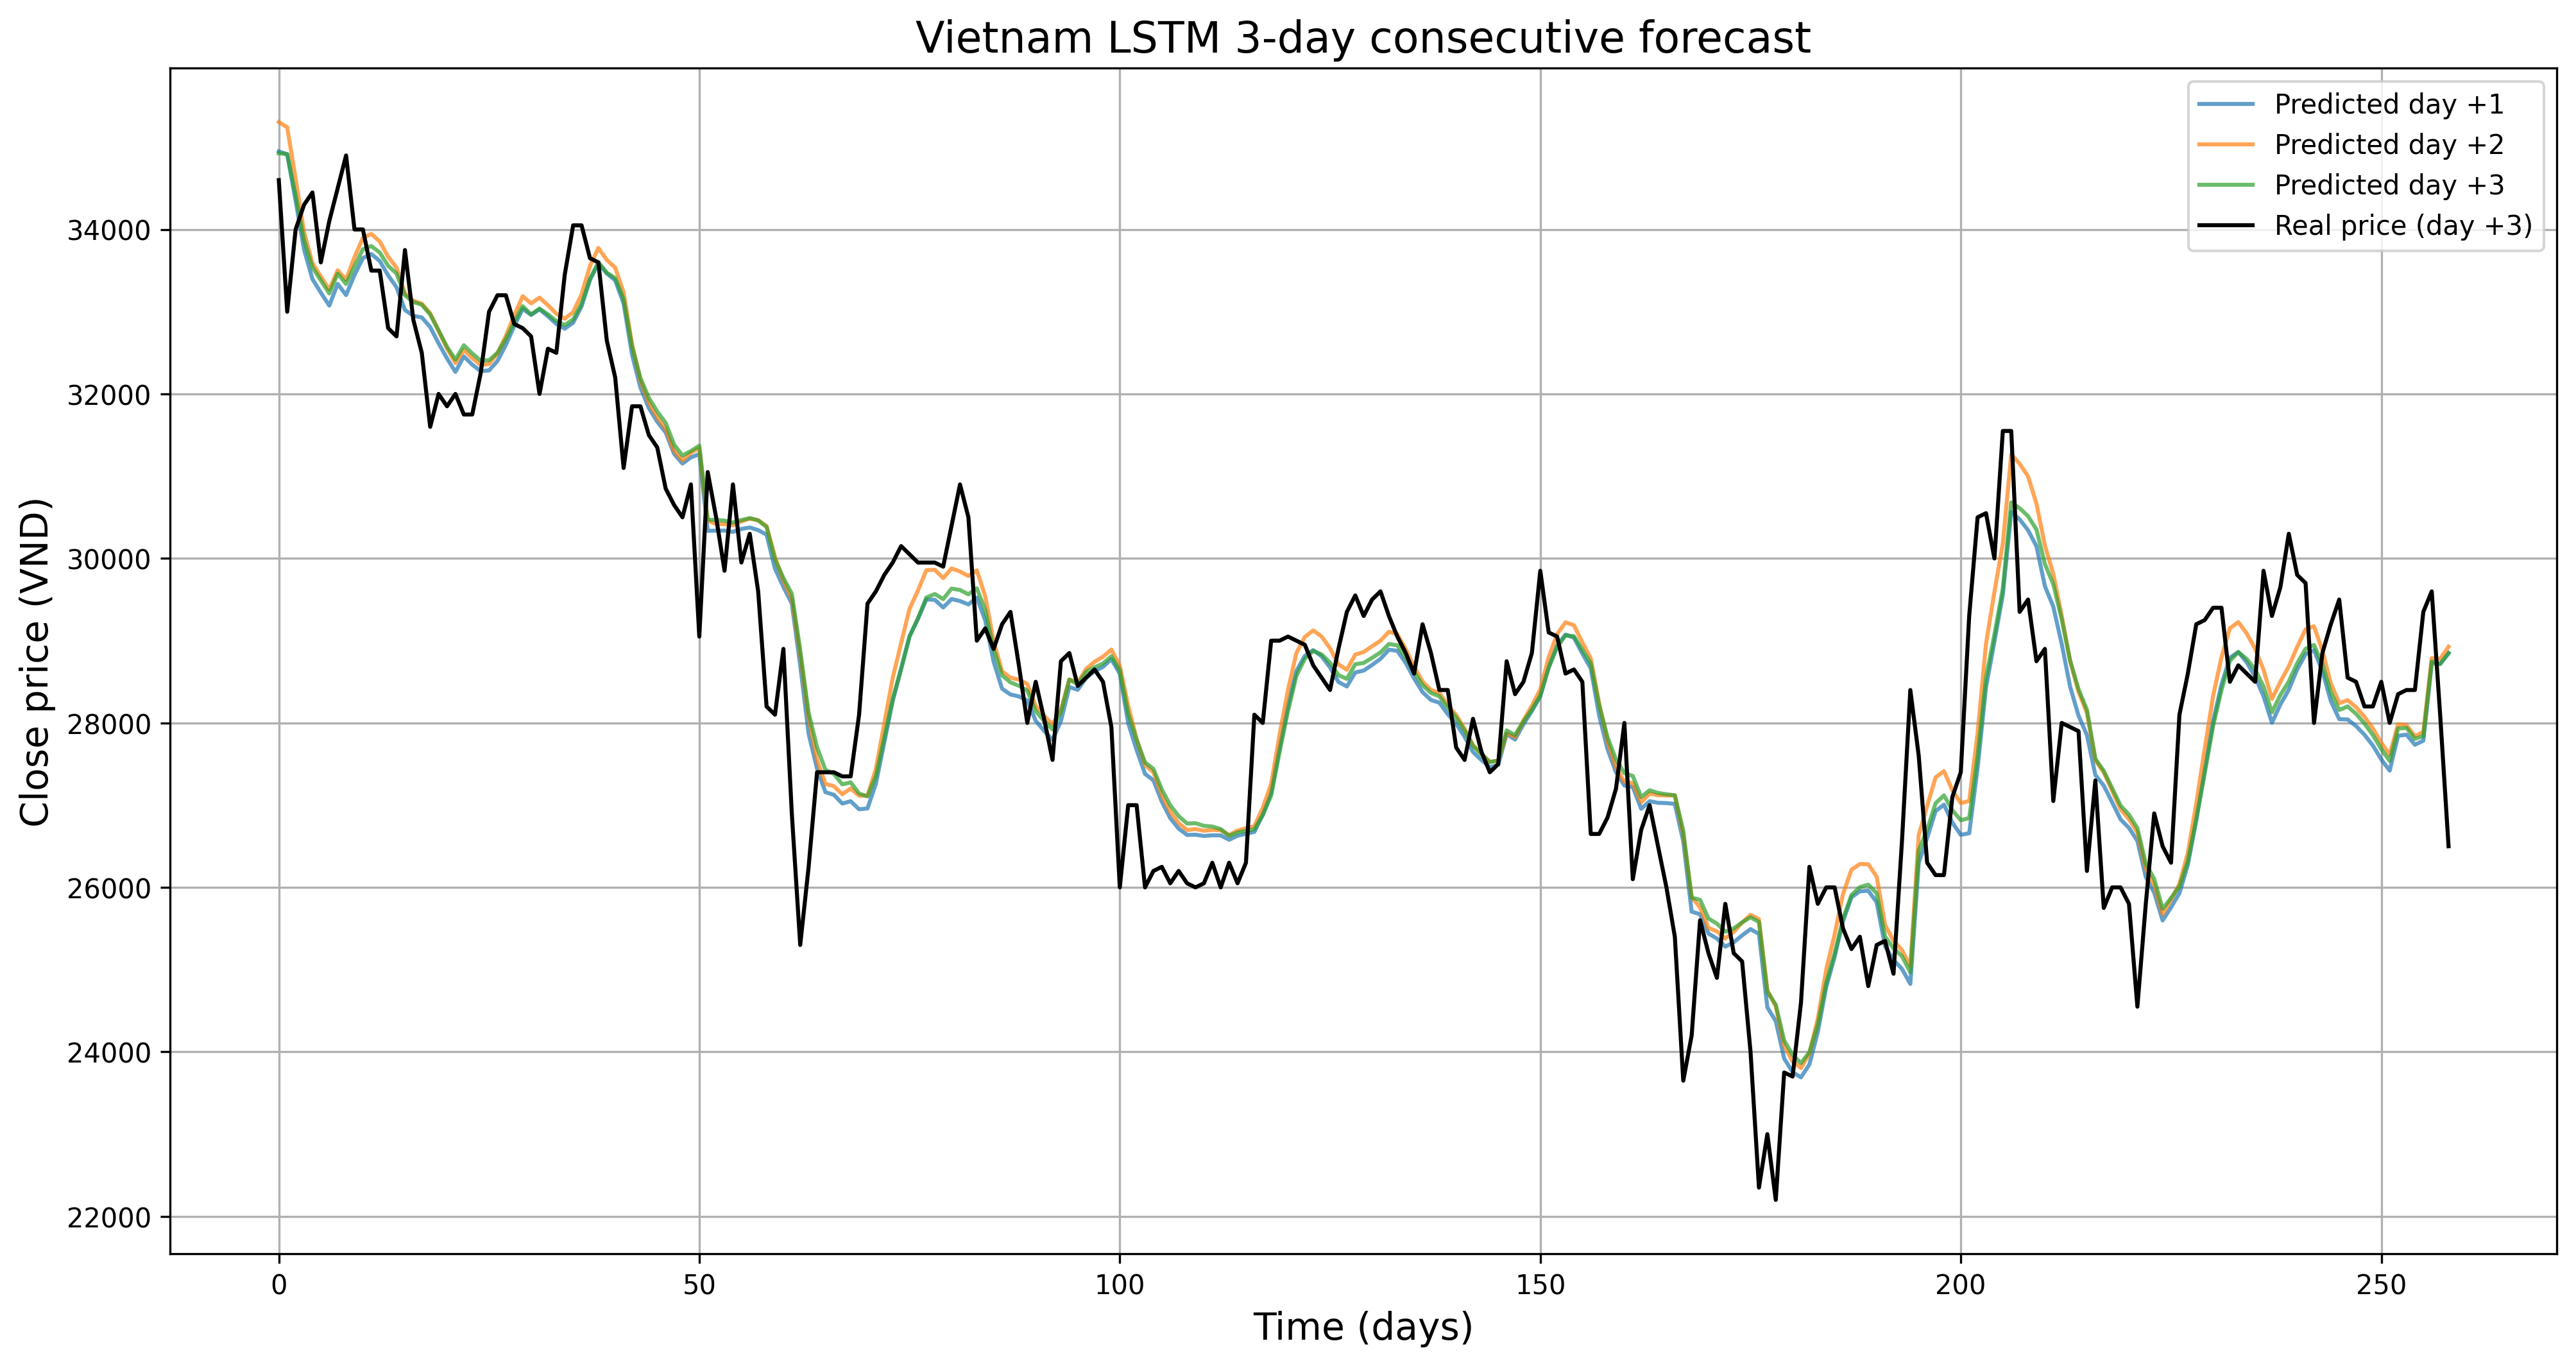

Day +1  RMSE: 1092.7741  MAE: 839.7013
Day +2  RMSE: 1268.3219  MAE: 981.4676
Day +3  RMSE: 1417.0906  MAE: 1096.2337


In [ ]:
#@title training/loading and evaluating
X_train, X_val, X_test, y_train, y_val, y_test = split_data(X_vn, y_vn)
X_train_norm, y_train_norm, _, _           = normalize_windows(X_train, y_train, VN_CLOSE_IDX)
X_val_norm,   y_val_norm,   _, _           = normalize_windows(X_val,   y_val,   VN_CLOSE_IDX)
X_test_norm,  y_test_norm,  t_mins, t_maxs = normalize_windows(X_test,  y_test,  VN_CLOSE_IDX)

model_vn_kdays, history = train_or_load_lstm(
    f'{MODEL_DIR}/task2_3_{FORECAST_DAYS}days.keras',
    window_size, len(VN_FEATURES), FORECAST_DAYS,
    X_train_norm, y_train_norm, X_val_norm, y_val_norm
)

_ = evaluate_and_plot(model_vn_kdays, X_test_norm, y_test, t_mins, t_maxs,
                  close_idx=VN_CLOSE_IDX, currency='VND',
                  title=f'Vietnam LSTM {FORECAST_DAYS}-day consecutive forecast')